In [149]:
import pandas as pd
import numpy as np
from numpy.random import logistic
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [131]:
def logregress(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)
    solvers = ['sag', 'newton-cg', 'newton-cholesky', 'lbfgs', "saga"]
    penalties = ['l2', 'l1', 'elasticnet', None]
    scores = []
    for s in solvers:
        for p in penalties:
            try:
                lr = LogisticRegression(penalty=p, solver=s, l1_ratio=0.5)
                lr.fit(X_train, y_train)
            except ValueError:
                continue

            y_pred = lr.predict(X_test)
            scores.append([s, p, str(round(accuracy_score(y_test, y_pred) * 100, 3)) + "%"])

    df_scores = pd.DataFrame(scores, columns=["Solver", 'Penalty', 'Score'])
    df_scores.sort_values('Score', ascending=False, inplace=True)
    return df_scores

In [64]:
hr = pd.read_csv("HR_comma_sep.csv")
hr.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

In [65]:
dum_hr = pd.get_dummies(hr, drop_first=True)
X = dum_hr.drop('left', axis=1)
y = dum_hr['left']

In [66]:
y.value_counts()

left
0    11428
1     3567
Name: count, dtype: int64

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

In [68]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_prob = lr.predict_proba(X_test)

In [69]:
y_pred_prob

array([[0.61099181, 0.38900819],
       [0.61344312, 0.38655688],
       [0.5404661 , 0.4595339 ],
       ...,
       [0.94840852, 0.05159148],
       [0.9446712 , 0.0553288 ],
       [0.78286529, 0.21713471]], shape=(4499, 2))

In [70]:
a = np.array([9,4,5,89,23,45])
a.argmax(), a.max()

(np.int64(3), np.int64(89))

In [71]:
a = np.array([[9,10],
             [34,2],
             [56, 4],
             [102, 200]])
a.argmax(axis=1), a.max(axis=1)

(array([1, 0, 0, 1]), array([ 10,  34,  56, 200]))

In [72]:
y_pred = y_pred_prob.argmax(axis=1)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(4499,))

In [73]:
#Argmax in short:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test) #Applies argmax to predicted probabilities matrix
accuracy_score(y_test, y_pred)

0.7983996443654146

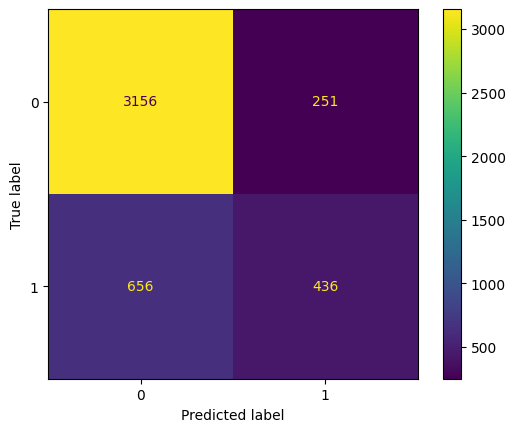

In [74]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
plt.show()

In [75]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7983996443654146

In [76]:
y.value_counts(normalize=True)*100

left
0    76.212071
1    23.787929
Name: proportion, dtype: float64

#### Stratification of Sampling

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)

In [78]:
y_train.value_counts(normalize=True)*100

left
0    76.209985
1    23.790015
Name: proportion, dtype: float64

In [79]:
y_train.value_counts()

left
0    7999
1    2497
Name: count, dtype: int64

In [80]:
y_test.value_counts(normalize=True)*100

left
0    76.216937
1    23.783063
Name: proportion, dtype: float64

In [81]:
y_test.value_counts()

left
0    3429
1    1070
Name: count, dtype: int64

In [82]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test) #Applies argmax to predicted probabilities matrix

In [83]:
accuracy_score(y_test, y_pred)

0.8077350522338297

In [84]:
lr = LogisticRegression(penalty='l1', solver='liblinear')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.8012891753723049

In [85]:
lr = LogisticRegression(penalty='l2', solver='liblinear')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.7990664592131584

In [86]:
lr = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.757723938653034

In [87]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.8077350522338297

In [132]:
logregress(X, y)

,Solver,Penalty,Score
2,newton-cg,l2,66.154%
4,newton-cholesky,l2,66.154%
6,lbfgs,l2,66.154%
3,newton-cg,None,63.077%
5,newton-cholesky,None,63.077%
7,lbfgs,None,61.538%
0,sag,l2,53.846%
1,sag,None,53.846%
8,saga,l2,53.846%
9,saga,l1,53.846%


In [90]:
cancer = pd.read_csv(r"BreastCancer.csv")
cancer.head()

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
0,61634,5,4,3,1,2,2,2,3,1,Benign
1,63375,9,1,2,6,4,10,7,7,2,Malignant
2,76389,10,4,7,2,2,8,6,1,1,Malignant
3,95719,6,10,10,10,8,10,7,10,7,Malignant
4,128059,1,1,1,1,2,5,5,1,1,Benign


In [98]:
X = cancer.drop(["Code","Class"], axis=1)
y = cancer["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25, stratify=y)

In [100]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.9666666666666667

In [133]:
logregress(X, y)

,Solver,Penalty,Score
2,newton-cg,l2,66.154%
4,newton-cholesky,l2,66.154%
6,lbfgs,l2,66.154%
3,newton-cg,None,63.077%
5,newton-cholesky,None,63.077%
7,lbfgs,None,61.538%
0,sag,l2,53.846%
1,sag,None,53.846%
8,saga,l2,53.846%
9,saga,l1,53.846%


### Broken Glass Classification

In [111]:
glass = pd.read_csv(r"Glass.csv")
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


In [151]:
X = glass.drop("Type", axis=1)
le = LabelEncoder()
y = le.fit_transform(glass["Type"])

In [152]:
logregress(X, y)

,Solver,Penalty,Score
2,newton-cg,l2,66.154%
4,newton-cholesky,l2,66.154%
6,lbfgs,l2,66.154%
3,newton-cg,None,63.077%
5,newton-cholesky,None,63.077%
7,lbfgs,None,61.538%
0,sag,l2,53.846%
1,sag,None,53.846%
8,saga,l2,53.846%
9,saga,l1,53.846%


In [146]:
print(classification_report(y_test, y_pred))


                                      precision    recall  f1-score   support

    building_windows_float_processed       0.65      0.71      0.68        21
building_windows_non_float_processed       0.61      0.74      0.67        23
                          containers       0.50      0.50      0.50         4
                           headlamps       0.89      0.89      0.89         9
                           tableware       1.00      0.33      0.50         3
     vehicle_windows_float_processed       0.00      0.00      0.00         5

                            accuracy                           0.66        65
                           macro avg       0.61      0.53      0.54        65
                        weighted avg       0.63      0.66      0.63        65

